In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(0)
torch.manual_seed(0)

# Inline plot 
plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['axes.grid'] = False

In [2]:
# 2) Data
X, y = make_moons(n_samples=1000, noise=0.25, random_state=0)
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

def make_grid(X, n=300, pad=0.5):
    xmin, xmax = X[:,0].min()-pad, X[:,0].max()+pad
    ymin, ymax = X[:,1].min()-pad, X[:,1].max()+pad
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, n), np.linspace(ymin, ymax, n))
    Xg = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, Xg

xx, yy, Xg = make_grid(X)

In [21]:
# 3) Feature maps + standardization 
def fmap_deg1(X): 
    return X 

def fmap_deg2(X): # expand each point with squares and interactions 
    x1, x2 = X[:,0], X[:,1]
    return np.stack([x1, x2, 
                     x1**2, x1*x2, x2**2], axis=1) # 5 features 

def fmap_deg3(X): 
    x1, x2 = X[:,0], X[:,1]
    return np.stack([
        x1, x2, 
        x1**2, x1*x2, x2**2, 
        x1**3, (x1**2)*x2, x2*(x2**2), x2**3
    ], axis=1) # 9 features

def standardize_train_test(XtrF, XvaF):
    mu = XtrF.mean(0); sd = XtrF.std(0); sd[sd==0] = 1.0
    return (XtrF-mu)/sd, (XvaF-mu)/sd, mu, sd

In [23]:
# 4) NumPy logistic regression (generic)

def sigmoid(z): 
    z = np.clip(z, -50, 50)
    return 1.0/(1.0+np.exp(-z))

def add_bias(X): 
    return np.c_[np.ones((X.shape[0], 1)), X]

def logreg_numpy(Xtr, ytr, Xva, yva, fmap, lr=0.1, lam=3e-3, epochs=2000, seed=0):
    rng = np.random.default_rng(seed)
    XtrF = fmap(Xtr)
    XvaF = fmap(Xva)
    XtrS, XvaS, mu, sd = standardize_train_test(XtrF, XvaF)
    XtrB, XvaB = add_bias(XtrS), add_bias(XvaS)

    w = rng.normal(0, 0.01, XtrB.shape[1])
    for e in range(epochs): 
        p = sigmoid(XtrB @ w)
        g = (XtrB.T @ (p-ytr)) / ytr.size 
        g[1:] += 2*lam*w[1:]
        w -= lr*g 

    pva = sigmoid(XvaB @ w)
    acc = accuracy_score(yva, (pva>0.5).astype(int))
    return w, (mu, sd), acc, lambda Xgrid: sigmoid(add_bias((fmap(Xgrid)-mu)/sd) @ w)

# quick sanity: linear and deg2
w1, stats1, acc1, f1 = logreg_numpy(Xtr, ytr, Xva, yva, fmap_deg1, lr=0.1, lam=1e-3)
w2, stats2, acc2, f2 = logreg_numpy(Xtr, ytr, Xva, yva, fmap_deg2, lr=0.1, lam=3e-3)
print("Numpy deg1 acc:", acc1, "| NumPy deg2 acc:", acc2)

Numpy deg1 acc: 0.86 | NumPy deg2 acc: 0.865


In [25]:
# 5) PyTorch logistic regression (deg=3)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
# mps = MPS (Metal Performance Shaders) Torch refers to the PyTorch backend that enables GPU acceleration on Apple devices, specifically those with Apple Silicon (M1, M2, etc.) and running macOS 12.3 or later

class LogReg(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.lin = nn.Linear(d,1)
    def forward(self, x):
        return self.lin(x).squeeze(1) # logits 
    
def train_logreg_torch(Xtr, ytr, Xva, yva, fmap, lr=1e-2, lam=3e-2, epochs=2000, batch=128, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    XtrF, XvaF = fmap(Xtr), fmap(Xva)
    XtrS, XvaS, mu, sd = standardize_train_test(XtrF, XvaF)

    Xtr_t = torch.tensor(XtrS, dtype=torch.float32, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)
    Xva_t = torch.tensor(XvaS, dtype=torch.float32, device=device)
    yva_t = torch.tensor(yva, dtype=torch.float32, device=device)

    model = LogReg(d=XtrS.shape[1]).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=lam)
    loss_fn = nn.BCEWithLogitsLoss()

    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)
    best_acc, best_state = -1, None
    for e in range(1, epochs+1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if e % 200 == 0 or e == 1: 
            model.eval()
            with torch.no_grad():
                acc = (torch.sigmoid(model(Xva_t))>0.5).eq(yva_t).float().mean().item()
            if acc > best_acc:
                best_acc = acc
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

    if best_state: model.load_state_dict(best_state)
    model.eval()

    # closure for grid evaluation
    def grid_fn(Xgrid_np):
        XgS = (fmap(Xgrid_np) - mu) / sd
        with torch.no_grad():
            logits = model(torch.tensor(XgS, dtype=torch.float32, device=device))
            return torch.sigmoid(logits).cpu().numpy()
    return model, (mu, sd), best_acc, grid_fn

model3, stats3, acc3, f3 = train_logreg_torch(Xtr, ytr, Xva, yva, fmap=fmap_deg3, lr=1e-2, lam=3e-2, epochs=2000, batch=128)
print("PyTorch deg3 acc:", acc3)

PyTorch deg3 acc: 0.9449999928474426


In [26]:
# 6) Tiny MLP (no feature engineering)
class MLP(nn.Module):
    def __init__(self, d=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x).squeeze(1)

def train_mlp_torch(Xtr, ytr, Xva, yva, lr=1e-2, lam=0.0, epochs=1500, batch=128, seed=0):
    torch.manual_seed(seed)
    # standardize raw features too
    mu = Xtr.mean(0); sd = Xtr.std(0); sd[sd==0]=1
    XtrS, XvaS = (Xtr-mu)/sd, (Xva-mu)/sd

    Xtr_t = torch.tensor(XtrS, dtype=torch.float32, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)
    Xva_t = torch.tensor(XvaS, dtype=torch.float32, device=device)
    yva_t = torch.tensor(yva, dtype=torch.float32, device=device)

    model = MLP(d=2).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=lam)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)

    best_acc, best_state = -1, None
    for e in range(1, epochs+1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if e % 200 == 0 or e == 1:
            model.eval()
            with torch.no_grad():
                acc = (torch.sigmoid(model(Xva_t))>0.5).eq(yva_t).float().mean().item()
            if acc > best_acc:
                best_acc = acc
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if best_state: model.load_state_dict(best_state)
    model.eval()

    def grid_fn(Xgrid_np):
        XgS = (Xgrid_np - mu) / sd
        with torch.no_grad():
            logits = model(torch.tensor(XgS, dtype=torch.float32, device=device))
            return torch.sigmoid(logits).cpu().numpy()
    return model, (mu, sd), best_acc, grid_fn

mlp, stats_mlp, acc_mlp, fmlp = train_mlp_torch(Xtr, ytr, Xva, yva, lr=1e-2, lam=1e-3, epochs=1500, batch=128)
print("PyTorch MLP (raw) acc:", acc_mlp)

PyTorch MLP (raw) acc: 0.9649999737739563


In [28]:
# 7) Plotting utility
def plot_boundary(ax, fn_grid, title):
    Z = fn_grid(Xg).reshape(xx.shape)
    ax.contourf(xx, yy, (Z>0.5), alpha=0.20, cmap="coolwarm")
    ax.scatter(X[:,0], X[:,1], c=y, s=12, cmap="coolwarm", edgecolor="k", linewidths=0.3)
    ax.set_title(title)

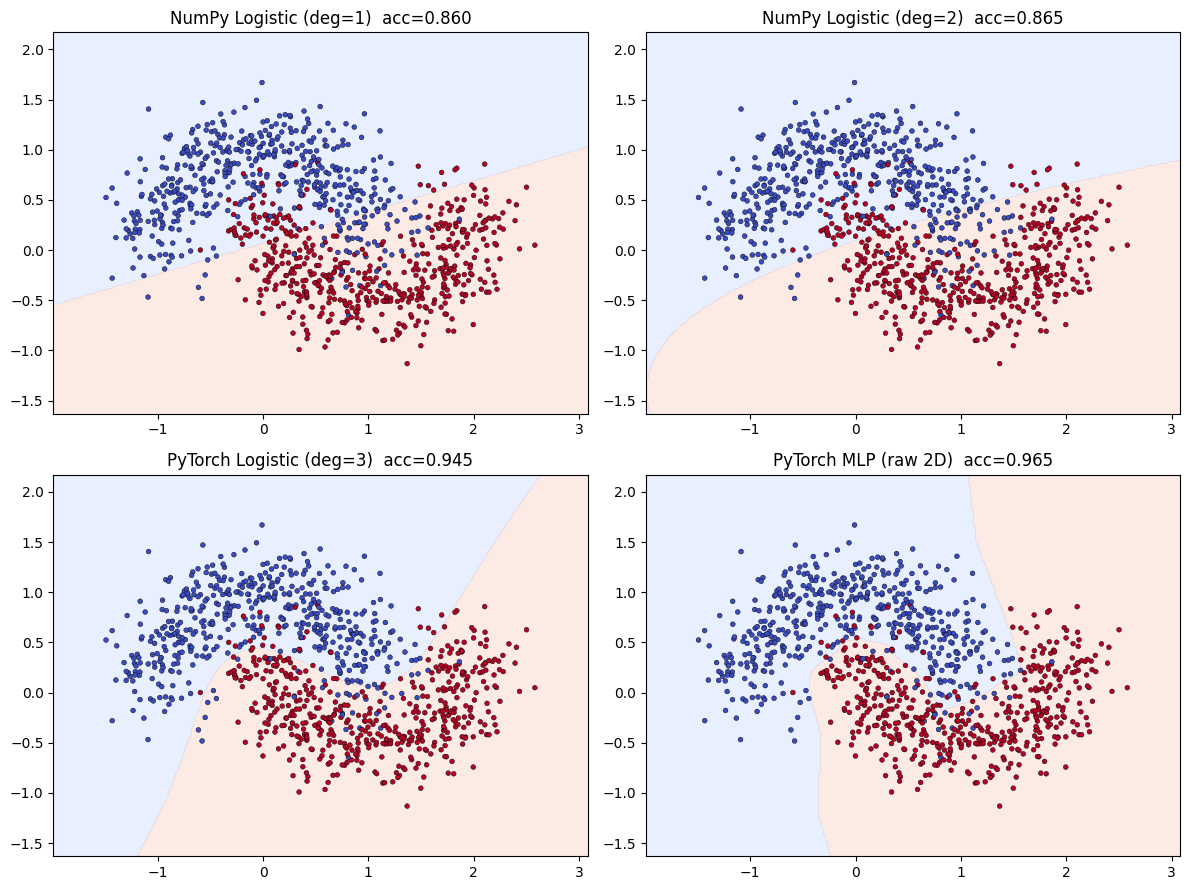

Saved grid → figs/decision_boundaries_grid.png


<Figure size 700x500 with 0 Axes>

In [29]:
# 8) Compare all four in a grid
fig, axs = plt.subplots(2, 2, figsize=(12,9))
plot_boundary(axs[0,0], f1, f"NumPy Logistic (deg=1)  acc={acc1:.3f}")
plot_boundary(axs[0,1], f2, f"NumPy Logistic (deg=2)  acc={acc2:.3f}")
plot_boundary(axs[1,0], f3, f"PyTorch Logistic (deg=3)  acc={acc3:.3f}")
plot_boundary(axs[1,1], fmlp, f"PyTorch MLP (raw 2D)  acc={acc_mlp:.3f}")
plt.tight_layout()
plt.show()

# Save figure
from pathlib import Path
Path("figs").mkdir(exist_ok=True)
plt.savefig("figs/decision_boundaries_grid.png", dpi=160, bbox_inches="tight")
print("Saved grid → figs/decision_boundaries_grid.png")